In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

In [2]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [3]:
class Value:
    def __init__(self, data, label = '', parents=(), _op=None):
        self.data = data
        self._prev = set(parents)
        self.label = label
        self.grad = 0
        self._op = _op
        self._backward = lambda: None
    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data + other.data, parents=(self, other), _op='+')
        def _backward():
            self.grad += result.grad
            other.grad += result.grad
        result._backward = _backward
        return result
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data * other.data, parents=(self, other), _op='*')
        def _backward():
            self.grad += result.grad * other.data
            other.grad += result.grad * self.data
        result._backward = _backward
        return result
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def tanh(self):
        # tanh = lambda x: (1 - np.e ** (-2*x))/(1 + np.e ** (-2*x))
        tanh = np.tanh
        result = Value(data = tanh(self.data), parents=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - result.data ** 2) * result.grad
        result._backward = _backward
        return result
    def exp(self): 
        result = Value(np.e**self.data, parents=(self,), _op='exp')
        def _backward():
            # print(result.data, result.grad)
            self.grad += result.data * result.grad
        result._backward = _backward
        return result
    def __pow__(self, other):
        # Here other is int or float, not Value
        result = Value(self.data ** other, parents=(self,), _op=f'**{other}')
        def _backward():
            self.grad += other * self.data**(other-1) * result.grad
        result._backward = _backward
        return result
    def __truediv__(self, other):
        return self * other ** -1
    def __rtruediv__(self, other):
        return other * self ** -1
    def __radd__(self, other):
        return self + other
    def __rsub__(self, other):
        return (-self) + other
    def __rmul__(self, other):
        return self * other
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad}, label={self.label})"
    def zero_grad(self):
        # can be called on the final output node in the training loop to clear all grads
        # works fine on intermediate nodes also, will delete all it's parent's grads (childrens?)
        if self.grad != 0: # so recursion does not repeat following multiple paths
            self.grad = 0
            for p in self._prev:
                p.zero_grad()
    def backward(self, is_result=True):
        self.grad = 1.0
        node_list = []
        def traverse(node):
            # print(node)
            for n in node._prev:
                if n not in node_list: # assuming no back edges (ie, acyclic)
                    traverse(n)
            node_list.append(node)
        traverse(self)
        node_list.reverse()
        # print("Topo Order:")
        # for ele in node_list:
        #     print(ele)
        for node in node_list:
            node._backward()

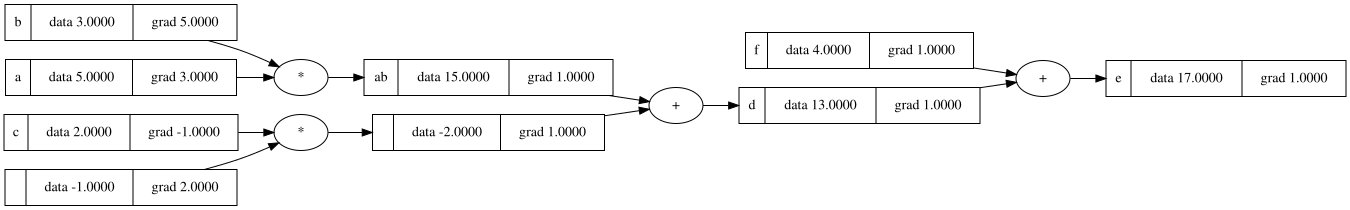

In [5]:
a = Value(5)
a.label = 'a'
b = Value(3)
b.label = 'b'
c = Value(2)
c.label = 'c'
ab = a * b
ab.label = 'ab'
d = ab + (-c)
d.label = 'd'
f = Value(4)
f.label = 'f'
e = d + f
e.label = 'e'

e.zero_grad()
e.backward()
draw_dot(e)

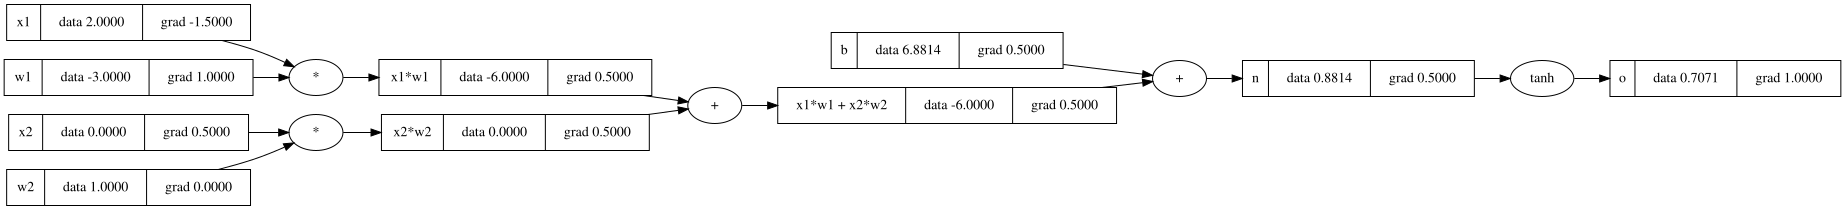

In [4]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.zero_grad()
o.backward()

draw_dot(o)

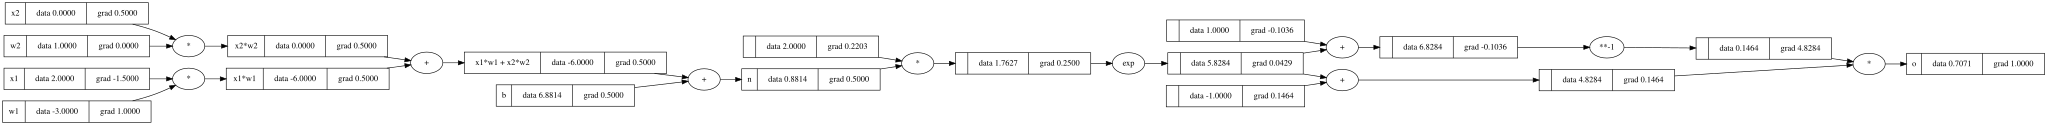

In [7]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# # ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.zero_grad()
o.backward()
draw_dot(o)



In [8]:
import torch


In [9]:
x1 = torch.tensor(2., requires_grad=True)
x2 = torch.tensor(0., requires_grad=True)
w1 = torch.tensor(-3., requires_grad=True)
w2 = torch.tensor(1., requires_grad=True)
b = torch.tensor(6.8814, requires_grad=True)
o = torch.tanh(x1*w1 + x2*w2 + b)
o


tensor(0.7071, grad_fn=<TanhBackward0>)

In [10]:
o.backward()

In [11]:
o.grad

/tmp/ipykernel_28236/3391283232.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  o.grad


In [36]:
class Neuron:
    def __init__(self, n_in, label=''):
        self.weights = [Value(np.random.uniform(-1,1), label=f'{label}_w{i}') for i in range(n_in)]
        self.bias = Value(np.random.uniform(-1,1), label=label+'_b')
    def __call__(self, x):
        sum = 0 + self.bias
        assert len(x) == len(self.weights)
        for x,w in zip(x, self.weights):
            sum += x * w
        return sum
    def parameters(self):
        return self.weights + [self.bias]
    def __repr__(self):
        return f"Neuron(in_dim={len(self.weights)}, weights={self.weights}, bias={self.bias})"
    
class Layer:
    def __init__(self, in_dim, out_dim, label=''):
        self.neurons = [Neuron(in_dim, label=f'{label}_n{n_idx}') for n_idx in range(out_dim)]
    def __call__(self, x):
        return [n(x) for n in self.neurons]
    def parameters(self):
        params = []
        for n in self.neurons:
            params += n.parameters()
        return params
    def __repr__(self):
        return f"Layer(in_dim={len(self.neurons[0].weights)}, out_dim={len(self.neurons)})"

class MLP:
    def __init__(self, dim_list):
        self.layers = [Layer(dim_list[dim_idx - 1], dim_list[dim_idx], label=f'l{dim_idx-1}') for dim_idx in range(1, len(dim_list))]
        self.layer_ops = None
    def __call__(self, x):
        self.layer_ops = []
        # single input x (not batch)
        for l in self.layers:
            x = l(x)
            x = [x_i.tanh() for x_i in x]
            self.layer_ops.append(x)
        if len(x) == 1:
            x = x[0]
        return x
    def parameters(self):
        params = []
        for l in self.layers:
            params += l.parameters()
        return params


In [ ]:

np.random.seed(5)
dim_list = [2,3,5,1]
mlp = MLP(dim_list)

In [7]:
mlp.layers

[Layer(in_dim=2, out_dim=3),
 Layer(in_dim=3, out_dim=5),
 Layer(in_dim=5, out_dim=1)]

In [8]:
dataset_0 = {
    'x': [[2,3], [4,5], [3,2], [8,7]],
    'y': [-1, -1, 1, 1]
}
dataset = dataset_0

In [16]:
outputs = [mlp(x) for x in dataset['x']]
outputs

[Value(data=-0.6078064594936096, grad=0, label=),
 Value(data=-0.400960746200438, grad=0, label=),
 Value(data=-0.9206088281236234, grad=0, label=),
 Value(data=-0.6988084144920401, grad=0, label=)]

In [17]:
s = 0
for i, op in enumerate(outputs):
    val = (dataset['y'][i] - outputs[i].data)**2
    print(f'{i} label: {dataset['y'][i]} pred: {outputs[i].data:.2f} se: {val:.3f}')
    s += val
s

0 label: -1 pred: -0.61 se: 0.154
1 label: -1 pred: -0.40 se: 0.359
2 label: 1 pred: -0.92 se: 3.689
3 label: 1 pred: -0.70 se: 2.886


7.087352100623032

In [9]:
MSE = lambda y_pred, y_true: sum([(y_pred[i] - y_true[i])**2 for i in range(len(y_pred))])

loss = MSE(outputs, dataset['y'])
loss

NameError: name 'outputs' is not defined

In [19]:
loss.backward()

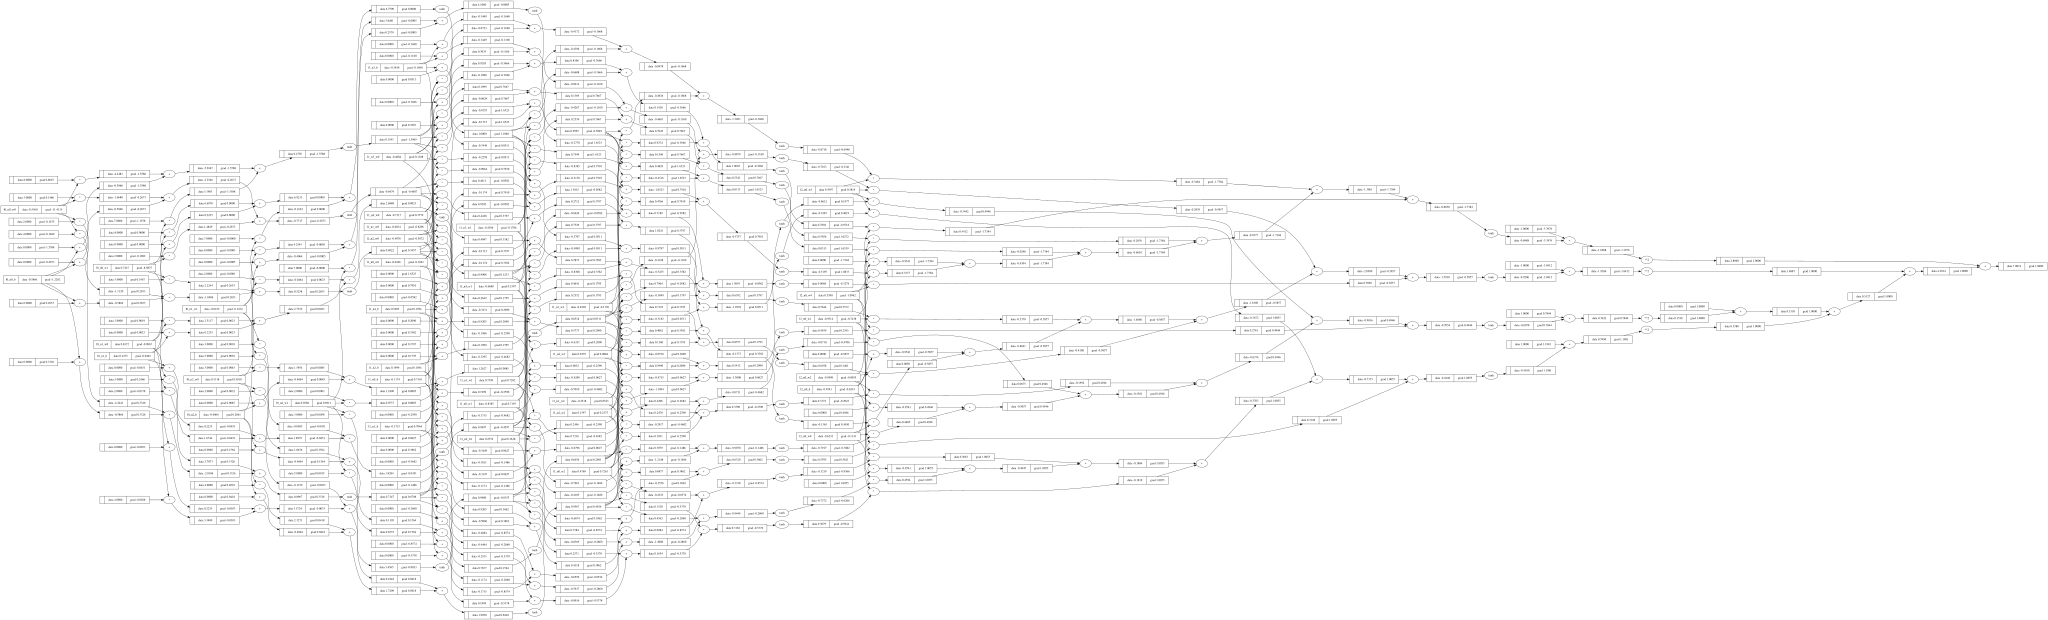

In [20]:
draw_dot(loss)

In [10]:
lr = 0.001
def train(mlp, dataset, lr=0.001, loss_fn=MSE):
    loss_list = []
    op_list = []
    for epoch in range(200):
        outputs = [mlp(x) for x in dataset['x']]
        loss = loss_fn(outputs, dataset['y'])
        loss.zero_grad()
        loss.backward()
        for p in mlp.parameters():
            p.data -= lr * p.grad
        print(f'Epoch:{epoch} Loss:{loss.data:.3f} Outputs:{[f'{o.data:.4f}' for o in outputs]}')
        loss_list.append(loss.data)
        op_list.append([o.data for o in outputs])
    return loss_list, op_list

In [11]:
loss_list, op_list = train(mlp, dataset)

Epoch:0 Loss:7.087 Outputs:['-0.6078', '-0.4010', '-0.9206', '-0.6988']
Epoch:1 Loss:6.859 Outputs:['-0.5892', '-0.3744', '-0.9156', '-0.6215']
Epoch:2 Loss:6.423 Outputs:['-0.5529', '-0.3296', '-0.9030', '-0.4671']
Epoch:3 Loss:6.022 Outputs:['-0.5068', '-0.2826', '-0.8787', '-0.3170']
Epoch:4 Loss:5.749 Outputs:['-0.4615', '-0.2425', '-0.8367', '-0.2293']
Epoch:5 Loss:5.480 Outputs:['-0.4214', '-0.2074', '-0.7684', '-0.1789']
Epoch:6 Loss:5.130 Outputs:['-0.3864', '-0.1730', '-0.6648', '-0.1393']
Epoch:7 Loss:4.702 Outputs:['-0.3551', '-0.1356', '-0.5277', '-0.0978']
Epoch:8 Loss:4.280 Outputs:['-0.3261', '-0.0926', '-0.3793', '-0.0490']
Epoch:9 Loss:3.945 Outputs:['-0.2993', '-0.0440', '-0.2475', '0.0081']
Epoch:10 Loss:3.707 Outputs:['-0.2768', '0.0078', '-0.1430', '0.0718']
Epoch:11 Loss:3.535 Outputs:['-0.2627', '0.0579', '-0.0635', '0.1387']
Epoch:12 Loss:3.393 Outputs:['-0.2630', '0.0997', '-0.0046', '0.2054']
Epoch:13 Loss:3.242 Outputs:['-0.2842', '0.1236', '0.0342', '0.2687'

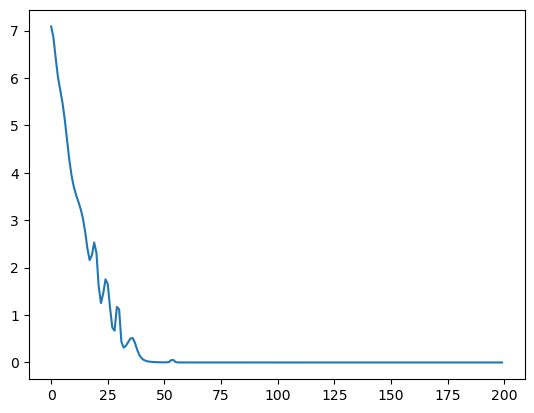

In [12]:
plt.plot(loss_list)
plt.show()

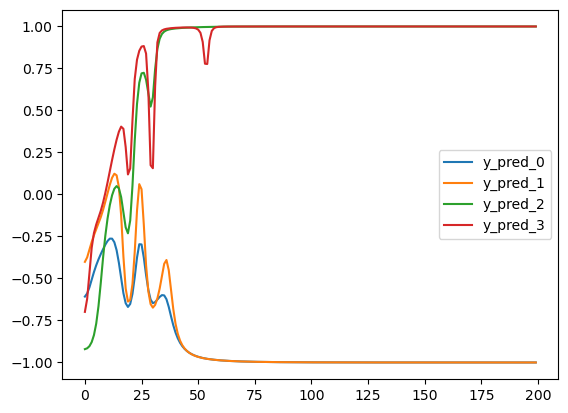

In [13]:
for x_i in range(4):
    plt.plot([ops[x_i] for ops in op_list], label=f'y_pred_{x_i}')
plt.legend()
plt.show()

### Training on MNIST

In [5]:
mnist_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

mnist_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

In [37]:
# mlp_2 = MLP(dim_list=[28*28, 40*40, 30*30, 10])
mlp_2 = MLP(dim_list=[7*7, 20, 10])
mlp_2.layers

[Layer(in_dim=49, out_dim=20), Layer(in_dim=20, out_dim=10)]

In [16]:
mnist_tr_ds = {}
mnist_te_ds = {}
mnist_tr_ds['x'] = [(np.array(sample[0].resize((7,7))).flatten()/255).tolist() for sample in mnist_train_dataset]
mnist_te_ds['x'] = [(np.array(sample[0].resize((7,7))).flatten()/255).tolist() for sample in mnist_test_dataset]

In [19]:
mnist_tr_ds['y'] = [[1 if i == sample[1] else 0 for i in range(10)] for sample in mnist_train_dataset]
mnist_te_ds['y'] = [[1 if i == sample[1] else 0 for i in range(10)] for sample in mnist_test_dataset]
mnist_tr_ds['y_int'] = [sample[1] for sample in mnist_train_dataset]
mnist_te_ds['y_int'] = [sample[1] for sample in mnist_test_dataset]

In [9]:
(np.array(mnist_tr_ds['y']).sum(axis=1)==1).all()

True

In [10]:
def MSE_loss(pred, labels):
    assert len(pred) == len(labels)
    if isinstance(pred[0], Value):
        return sum([(pred[n] - labels[n])**2 for n in range(len(pred))])
    # if multiple outputs (k)
    assert len(pred[0]) == len(labels[0])
    return sum([(pred[n][k] - labels[n][k])**2 for k in range(len(pred[0])) for n in range(len(pred))])

# def CE_loss(pred, labels):
#     assert len(pred) == len(labels)
#     if isinstance(pred[0], Value):
#         return sum([labels[n] * pred[n].log() + (1-labels[n]) * (1 - pred[n]).log() for n in range(len(pred))])
#     assert len(pred[0]) == len(labels[0])
#     return 

In [30]:
average = lambda x: sum(x)/len(x)
argmax = lambda a: a.index(max(a))
def check_saturation(layer_outputs):
    for l_i, l_op in enumerate(layer_outputs):
        np_op = np.array([v.data for v in l_op])
        print(f"L{l_i} saturated: {np.sum(np_op<-0.99) + np.sum(np_op>0.99)}/{len(np_op)}")
def accuracy(outputs, labels):
    assert len(outputs) == len(labels)
    pred_labels = [argmax([y_i.data for y_i in ops]) for ops in outputs]
    # print(pred_labels)
    return average([1 if pred_labels[i] == labels[i] else 0 for i in range(len(pred_labels))])

def train_mnist(mlp, dataset, lr=0.001, steps = 200, loss_fn=MSE_loss):
    loss_list = []
    accuracy_list = []
    prev_acc = 0
    for epoch in range(steps):
        outputs = [mlp(x) for x in dataset['x'][:10]]
        check_saturation(mlp.layer_ops)
        print(outputs)
        loss = loss_fn(outputs, dataset['y'][:10])
        print(loss)
        loss.zero_grad()
        loss.backward()
        for p in mlp.parameters():
            p.data -= lr * p.grad
        if epoch % 10 == 0:
            prev_acc = accuracy(outputs, dataset['y_int'][:10])
            accuracy_list.append(prev_acc)
        print(f'Epoch:{epoch} Loss:{loss.data:.3f} Accuracy:{prev_acc}')
        loss_list.append(loss.data)
        # op_list.append([o.data for o in outputs])
    return loss_list

In [ ]:
train_mnist(mlp_2, mnist_tr_ds, steps=300)

L0 saturated: 0/20
L1 saturated: 1/10
[[Value(data=-0.9947762277664763, grad=0, label=), Value(data=0.9778436853630327, grad=0, label=), Value(data=0.9283823246142329, grad=0, label=), Value(data=0.5211611397901861, grad=0, label=), Value(data=0.3649227173402257, grad=0, label=), Value(data=-0.9761733803945595, grad=0, label=), Value(data=0.8806450459752939, grad=0, label=), Value(data=0.9628960760778505, grad=0, label=), Value(data=-0.9768207135128115, grad=0, label=), Value(data=0.9462836152899956, grad=0, label=)], [Value(data=-0.9997094150014759, grad=0, label=), Value(data=0.9986394104198305, grad=0, label=), Value(data=0.9441324941114507, grad=0, label=), Value(data=0.39854628515104984, grad=0, label=), Value(data=-0.375809164252947, grad=0, label=), Value(data=-0.972462595417067, grad=0, label=), Value(data=0.9358983471538111, grad=0, label=), Value(data=0.5588852652191239, grad=0, label=), Value(data=-0.9987402170659927, grad=0, label=), Value(data=-0.12441521483828331, grad=0,